### Water Treatment Chemical Dosage Estimation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\Imarticus\ML\Synthesticwaterchemicaldosagedata.csv")
df

,pH,temperature,turbidity,conductivity,dosage
0,7.677850,22.910119,9.731775,189.256816,67.845426
1,7.189443,14.987852,7.713207,423.373966,134.665916
2,7.353841,10.722619,9.884347,207.131558,69.239718
3,6.063348,21.268349,7.948399,221.761188,75.077615
4,6.610757,11.971480,0.695792,120.672991,41.212825
...,...,...,...,...,...
995,7.095075,21.474119,1.512379,324.310924,105.151026
996,6.478519,28.342622,8.637819,460.812010,146.733718
997,6.061814,13.986223,6.010447,329.542891,105.891202
998,6.749788,13.434484,1.613568,205.245287,67.427001


In [3]:
df.head()

,pH,temperature,turbidity,conductivity,dosage
0,7.677850,22.910119,9.731775,189.256816,67.845426
1,7.189443,14.987852,7.713207,423.373966,134.665916
2,7.353841,10.722619,9.884347,207.131558,69.239718
3,6.063348,21.268349,7.948399,221.761188,75.077615
4,6.610757,11.971480,0.695792,120.672991,41.212825


In [4]:
df.tail()

,pH,temperature,turbidity,conductivity,dosage
995,7.095075,21.474119,1.512379,324.310924,105.151026
996,6.478519,28.342622,8.637819,460.812010,146.733718
997,6.061814,13.986223,6.010447,329.542891,105.891202
998,6.749788,13.434484,1.613568,205.245287,67.427001
999,7.211031,24.248725,1.789150,464.308419,147.715728


In [5]:
df.shape

(1000, 5)

In [6]:
df.columns

Index(['pH', 'temperature', 'turbidity', 'conductivity', 'dosage'], dtype='object')

In [7]:
df.dtypes

pH              float64
temperature     float64
turbidity       float64
conductivity    float64
dosage          float64
dtype: object

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pH            1000 non-null   float64
 1   temperature   1000 non-null   float64
 2   turbidity     1000 non-null   float64
 3   conductivity  1000 non-null   float64
 4   dosage        1000 non-null   float64
dtypes: float64(5)
memory usage: 39.2 KB


In [9]:
df.describe()

,pH,temperature,turbidity,conductivity,dosage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.020331,20.098368,5.075129,301.904335,98.637102
std,0.575443,5.753761,2.900123,112.615789,33.817642
min,6.000764,10.019172,0.008356,100.062126,36.626001
25%,6.545099,14.947061,2.569789,209.985050,71.509049
50%,7.043381,20.269362,5.084083,303.409840,98.799174
75%,7.514595,24.928135,7.628278,397.893738,126.997363
max,7.999906,29.992378,9.995484,498.448235,159.195092


In [10]:
df.isnull().sum()

pH              0
temperature     0
turbidity       0
conductivity    0
dosage          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.nunique()

pH              1000
temperature     1000
turbidity       1000
conductivity    1000
dosage          1000
dtype: int64

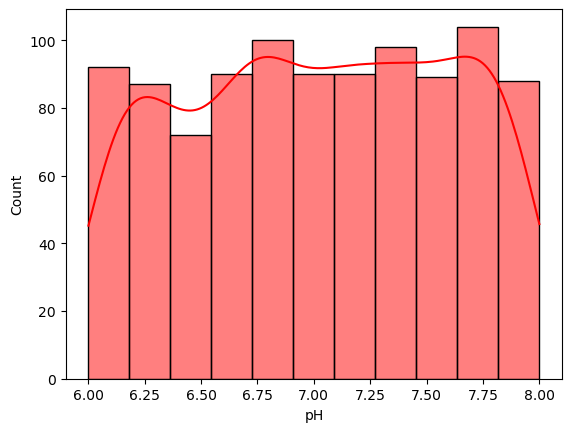

In [13]:
sns.histplot(df['pH'],color = 'red',kde = True)
plt.show()

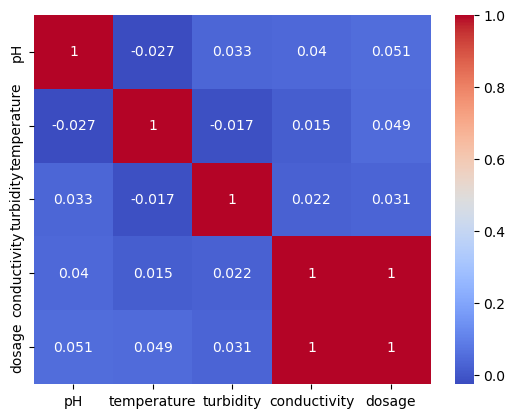

In [14]:
sns.heatmap(df.corr(numeric_only = True),
           annot = True,
           cmap = 'coolwarm')
plt.show()

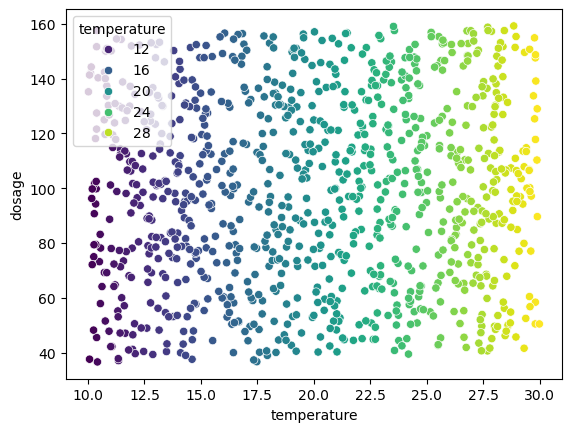

In [15]:
sns.scatterplot(x = 'temperature',y = 'dosage',palette="viridis",hue="temperature",data = df)
plt.show()

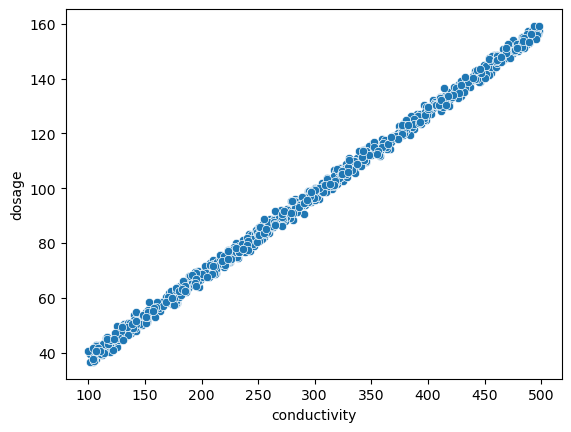

In [16]:
sns.scatterplot(x = 'conductivity',y = 'dosage',data = df)
plt.show()

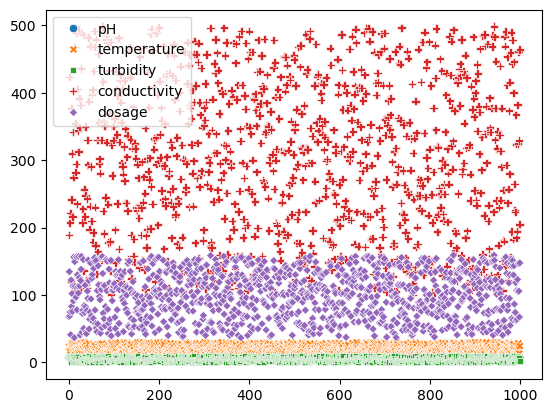

In [17]:
sns.scatterplot(data = df)
plt.show()

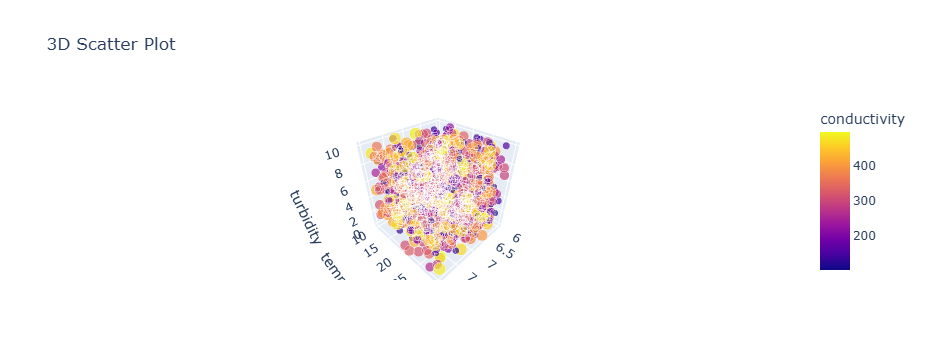

In [18]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='pH',
    y='temperature',
    z='turbidity',
    color='conductivity',
    size='dosage',
    title='3D Scatter Plot'
)

fig.show()

### KEY INSIGHTS

Correlation analysis revealed that conductivity has an exceptionally strong positive correlation with chemical dosage (r ≈ 1.00). The conductivity-versus-dosage scatter plot further confirms an almost perfect linear relationship. In contrast, pH, temperature, and turbidity show very weak correlations with dosage (|r| < 0.06). Therefore, conductivity appears to be the dominant predictor of dosage in this synthetic dataset.

In [19]:
# 1. Detect
Q1 = df['dosage'].quantile(0.25)
Q3 = df['dosage'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 2. Check outliers
outliers = df[(df['dosage'] < lower) | (df['dosage'] > upper)]

print("Number of outliers:", len(outliers))

# 3. Handle using capping
df['dosage'] = df['dosage'].clip(lower=lower, upper=upper)

Number of outliers: 0


### Linear Regression

In [20]:
x = df[['pH','temperature','turbidity','conductivity']]

In [21]:
x = df.drop('dosage',axis =1)

In [22]:
x

,pH,temperature,turbidity,conductivity
0,7.677850,22.910119,9.731775,189.256816
1,7.189443,14.987852,7.713207,423.373966
2,7.353841,10.722619,9.884347,207.131558
3,6.063348,21.268349,7.948399,221.761188
4,6.610757,11.971480,0.695792,120.672991
...,...,...,...,...
995,7.095075,21.474119,1.512379,324.310924
996,6.478519,28.342622,8.637819,460.812010
997,6.061814,13.986223,6.010447,329.542891
998,6.749788,13.434484,1.613568,205.245287


In [23]:
y = df[['dosage']]

In [24]:
y

,dosage
0,67.845426
1,134.665916
2,69.239718
3,75.077615
4,41.212825
...,...
995,105.151026
996,146.733718
997,105.891202
998,67.427001


In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [26]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [27]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
lr.coef_

array([[0.62559188, 0.20778948, 0.09725826, 0.29951959]])

In [29]:
lr.intercept_

array([-0.84241862])

In [30]:
y_predict = lr.predict(x_test)

In [31]:
# y_predict

In [32]:
from sklearn.metrics import (r2_score,mean_squared_error,mean_absolute_error,root_mean_squared_error,mean_absolute_percentage_error)

In [33]:
print("R2 Score : ",r2_score(y_test,y_predict))

R2 Score :  0.9990657751379748


In [34]:
print("MAE : ",mean_absolute_error(y_test,y_predict))

MAE :  0.802138009897825


In [35]:
print("MSE : ",mean_squared_error(y_test,y_predict))

MSE :  1.0647776716581223


In [36]:
print("RMSE : ",root_mean_squared_error(y_test,y_predict))

RMSE :  1.0318806479715192


In [37]:
print("MAPE : ",mean_absolute_percentage_error(y_test,y_predict))

MAPE :  0.008907244771324794


In [38]:
x.sample()

,pH,temperature,turbidity,conductivity
410,6.317992,27.988105,9.646957,390.466269


In [39]:
abc = pd.DataFrame([{'pH' : 6.7,
                    'temperature' : 15,
                    'turbidity' : 4,
                    'conductivity' : 250}])

In [40]:
abc_pred = lr.predict(abc)
abc_pred

array([[81.73482019]])

In [41]:
from sklearn.linear_model import Lasso,Ridge,ElasticNet

In [42]:
l1 = Lasso()
l1.fit(x_train,y_train)
y_predict_l1 = l1.predict(x_test)
print("L1 R2 Score:",r2_score(y_test,y_predict_l1))
print("L1 mean_squared_error:",mean_squared_error(y_test,y_predict_l1))
print("L1 mean_absolute_error:",mean_absolute_error(y_test,y_predict_l1))
print("L1 root_mean_squared_error:",root_mean_squared_error(y_test,y_predict_l1))
print("L1 mean_absolute_percentage_error:",mean_absolute_percentage_error(y_test,y_predict_l1))

L1 R2 Score: 0.9988446470292749
L1 mean_squared_error: 1.3168072228832848
L1 mean_absolute_error: 0.8830726704133184
L1 root_mean_squared_error: 1.1475222101917177
L1 mean_absolute_percentage_error: 0.010010496756146252


In [43]:
abc = pd.DataFrame([{'pH' : 6.7,
                    'temperature' : 15,
                    'turbidity' : 4,
                    'conductivity' : 250}])
abc_pred = l1.predict(abc)
abc_pred

array([82.19279589])

In [44]:
l2 = Ridge()
l2.fit(x_train,y_train)
y_predict_l2 = l2.predict(x_test)
print("L2 R2 Score:",r2_score(y_test,y_predict_l2))
print("L2 mean_squared_error:",mean_squared_error(y_test,y_predict_l2))
print("L2 mean_absolute_error:",mean_absolute_error(y_test,y_predict_l2))
print("L2 root_mean_squared_error:",root_mean_squared_error(y_test,y_predict_l2))
print("L2 mean_absolute_percentage_error:",mean_absolute_percentage_error(y_test,y_predict_l2))

L2 R2 Score: 0.9990656590171775
L2 mean_squared_error: 1.0649100197010473
L2 mean_absolute_error: 0.8021682119949951
L2 root_mean_squared_error: 1.0319447755093523
L2 mean_absolute_percentage_error: 0.008908407420031059


In [45]:
abc = pd.DataFrame([{'pH' : 6.7,
                    'temperature' : 15,
                    'turbidity' : 4,
                    'conductivity' : 250}])
abc_pred = l2.predict(abc)
abc_pred

array([81.73562243])

In [46]:
l12 = ElasticNet()
l12.fit(x_train,y_train)
y_predict_l12 = l12.predict(x_test)
print("L12 R2 Score:",r2_score(y_test,y_predict_l12))
print("L12 mean_squared_error:",mean_squared_error(y_test,y_predict_l12))
print("L12 mean_absolute_error:",mean_absolute_error(y_test,y_predict_l12))
print("L12 root_mean_squared_error:",root_mean_squared_error(y_test,y_predict_l12))
print("L12 mean_absolute_percentage_error:",mean_absolute_percentage_error(y_test,y_predict_l12))

L12 R2 Score: 0.9988972493512077
L12 mean_squared_error: 1.256854014455501
L12 mean_absolute_error: 0.8655946218251421
L12 root_mean_squared_error: 1.1210950068818881
L12 mean_absolute_percentage_error: 0.009815138189265842


In [47]:
abc = pd.DataFrame([{'pH' : 6.7,
                    'temperature' : 15,
                    'turbidity' : 4,
                    'conductivity' : 250}])
abc_pred = l12.predict(abc)
abc_pred

array([82.08698595])

In [48]:
print("training Accuracy:", lr.score(x_train, y_train))
print("testing Accuracy:", lr.score(x_test, y_test))

training Accuracy: 0.9992309634959389
testing Accuracy: 0.9990657751379748
